# 01 · The full peteksim workflow

From a synthetic Petrel-style export to a per-zone STOIIP P-curve and an
interactive 3-D view — the whole `peteksim` product surface in one pass.

Everything here runs on a **fully synthetic** asset (`ps.synth_asset`), so nothing
confidential is touched. The workflow is the declarative **API v2**: describe the
model as immutable *spec* values, then *apply* them at explicit moments
(`geom.build`, `grid.model`, `model.zoned_uncertainty`).

In [1]:
import tempfile, os
import petekio as pio
import peteksim as ps

print("peteksim", ps.version())

peteksim 0.1.1


## 1 · A synthetic asset on disk

`ps.synth_asset` fabricates a fictional multi-zone field — deviated wells, per-zone
contacts, a pinch-out — and returns a manifest of the names the specs consume.

In [2]:
root = tempfile.mkdtemp(prefix="nb1-asset-")
man  = ps.synth_asset(root, seed=20260704, n_wells=8)

print("horizons :", man["horizons"])
print("zones    :", man["zones"])
print("wells    :", man["well_ids"])
print("crs      :", man["crs"])
print("contacts :", {k: round(v, 1) for k, v in man["contacts"].items()})

horizons : ['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6']
zones    : ['Z0', 'Z1', 'Z2', 'Z3', 'Z4', 'Z5']
wells    : ['99_1-1', '99_2-1', '99_3-1', '99_4-1', '99_5-1', '99_6-1', '99_7-1', '99_8-1']
crs      : SYNTHETIC / ED50 UTM zone 31N
contacts : {'owc_z2': 1951.4, 'goc_z4': 1968.9, 'fwl_z4': 1974.5}


## 2 · Load the project

`pio.Project.import_data` walks the export tree; `pio.ImportSettings` carries the CRS and the alias
canonicalisation (e.g. `PHIT` -> `PORO`). `inventory()` reports what loaded and what
was skipped, with reasons.

In [3]:
proj = pio.Project.import_data(
    man["root"],
    settings=pio.ImportSettings(crs=man["crs"], aliases=man["aliases"]),
)
proj.inventory()

Inventory(surfaces=15, polygons=2, points=14, wells=8, tops=12, merged=0, skipped=0)

## 3 · Declare the model as specs

A **spec** holds *names*, not project objects — resolved at apply time. It says
either WHAT (`Horizons`, `Layering`, `Contacts`, `Props`) or HOW (`TieSettings`,
`Gridding`). Specs are immutable values: comparable, serializable, derivable.

In [4]:
hz = ps.Horizons(
    *[ps.hz(h) for h in man["horizons"]],        # one row per horizon, top -> down
    zones=man["zones"],                           # zones = horizons - 1
    ties=ps.TieSettings(method="convergent"),
    gridding=ps.Gridding(collapse=True),
)
lay = ps.Layering(nk=2)                           # layers per zone
con = ps.Contacts({z["zone"]: dict(z["contacts"])
                   for z in man["zonation"] if z["contacts"]})
props = ps.Props(
    ps.Prop("PORO", net_only=True,
            propagate=ps.Propagate(variogram=ps.variogram("spherical", 1500.0), seed=11)),
    ps.Prop("NTG",
            propagate=ps.Propagate(variogram=ps.variogram("spherical", 1500.0), seed=12)),
)

# A spec pretty-prints as its own domain table:
print(hz)

Horizons (stratigraphic column, top→down)
#  horizon  surface  tie  sd_m  vgm  zone_below
-  -------  -------  ---  ----  ---  ----------
0  H0       H0       H0   0          Z0        
1  H1       H1       H1   0          Z1        
2  H2       H2       H2   0          Z2        
3  H3       H3       H3   0          Z3        
4  H4       H4       H4   0          Z4        
5  H5       H5       H5   0          Z5        
6  H6       H6       H6   0                    


## 4 · Apply the specs at the explicit moments

Three moments turn specs into concrete objects:
`grid_geometry` -> `build` -> `model`. Errors here are loud, naming both the
missing project object and the spec entry.

In [5]:
geom  = proj.grid_geometry(cell=(50.0, 50.0), orient=0.0)
grid  = geom.build(hz, layering=lay, collapse_negative=True, min_thickness_m=0.0)
model = grid.model(props, con, fluid="oil", fvf=1.30, gas_fvf=0.005,
                   wells=proj.wells())

print("model:", model)
print("is_zoned:", model.is_zoned())

model: Model(zoned=True, props=['SW', 'PORO', 'NTG'])
is_zoned: True


## 5 · Read the model

All results are SI/metric: depths in **m** (positive down), volumes in **Sm³**
(reported **MSm³**), GRV in **mcm** (10⁶ m³).

In [6]:
s = model.summary()
print(f"field STOIIP = {s['stoiip_msm3']:.4f} MSm3   GRV = {s['grv_mcm']:.1f} mcm")

print("\nper-zone net PORO (mean):")
for r in model.zone_stats("PORO"):
    print(f"  {r['zone']:4s}  PORO~{r['mean']:.3f}  (n={r['count']})")

field STOIIP = 0.1995 MSm3   GRV = 694.7 mcm

per-zone net PORO (mean):
  Z0    PORO~0.229  (n=3200)
  Z1    PORO~0.270  (n=3200)
  Z2    PORO~0.278  (n=3200)
  Z3    PORO~0.246  (n=3200)
  Z4    PORO~0.295  (n=3200)
  Z5    PORO~0.252  (n=2560)


### Per-zone in-place

A contactless zone contributes gross rock with zero hydrocarbon; a two-contact zone
(gas cap + oil rim) is flagged.

In [7]:
byz = model.in_place_by_zone()
print(f"{'zone':6s}{'GRV_mcm':>10s}{'STOIIP_MSm3':>14s}{'two_contact':>14s}")
for r in byz["zones"]:
    print(f"{r['zone']:6s}{r['grv_mcm']:10.1f}{r['stoiip_msm3']:14.4f}{str(r['two_contact']):>14s}")
tot = byz["total"]
print(f"{'TOTAL':6s}{tot['grv_mcm']:10.1f}{tot['stoiip_msm3']:14.4f}")

zone     GRV_mcm   STOIIP_MSm3   two_contact
Z0         247.8        0.0000         False
Z1         193.5        0.0000         False
Z2           0.9        0.1024         False
Z3         142.5        0.0000         False
Z4           0.9        0.0970          True
Z5         109.1        0.0000         False
TOTAL      694.7        0.1995


## 6 · Zoned Monte Carlo — the P-curve

One `Mc` spec (porosity level-shift + contact/GOC pick-spread + draw count + seed)
routes to the zoned run and yields per-zone and field P-curves. Percentiles follow
the reservoir convention (**P90 low, P10 high**). We keep `n` modest to stay
fast.

In [8]:
mc = model.zoned_uncertainty(ps.Mc(porosity=0.01, contacts=4.0, goc=3.0,
                                   n=2000, seed=42))
t = mc.total["stoiip"]
print(f"field STOIIP  P90 = {t['p90_msm3']:.4f}  "
      f"P50 = {t['p50_msm3']:.4f}  P10 = {t['p10_msm3']:.4f}  MSm3")
print(f"mean = {t['mean_msm3']:.4f} MSm3 over {len(t['samples'])} draws")

field STOIIP  P90 = 0.0411  P50 = 0.2438  P10 = 0.7233  MSm3
mean = 0.3231 MSm3 over 2000 draws


In [9]:
# The hydrocarbon-bearing zones carry the spread:
print(f"{'zone':6s}{'P90':>9s}{'P50':>9s}{'P10':>9s}   MSm3")
for z in mc.zones:
    st = z["stoiip"]
    if st["p10_msm3"] > 0:
        print(f"{z['zone']:6s}{st['p90_msm3']:9.4f}{st['p50_msm3']:9.4f}{st['p10_msm3']:9.4f}")

zone        P90      P50      P10   MSm3
Z2       0.0000   0.1059   0.5100
Z4       0.0000   0.0961   0.3047


### Plot the field STOIIP distribution

`mc.total["stoiip"]["samples"]` is the full per-realization vector — histogram it
directly.

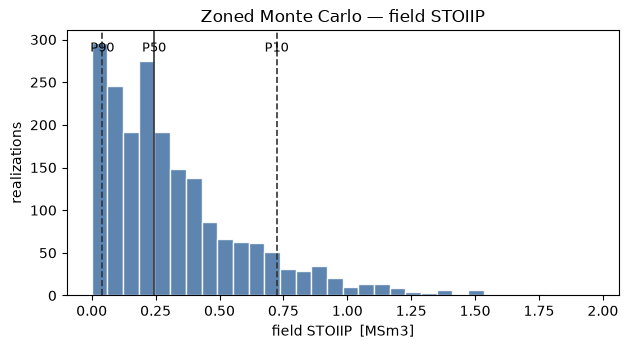

In [10]:
import matplotlib.pyplot as plt

samples_msm3 = [x / 1e6 for x in t["samples"]]
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.hist(samples_msm3, bins=32, color="#4C78A8", edgecolor="white", alpha=0.9)
for p, ls, lbl in [(t["p90_msm3"], "--", "P90"),
                   (t["p50_msm3"], "-",  "P50"),
                   (t["p10_msm3"], "--", "P10")]:
    ax.axvline(p, color="#333", linestyle=ls, linewidth=1.2)
    ax.text(p, ax.get_ylim()[1]*0.92, lbl, ha="center", fontsize=9)
ax.set_xlabel("field STOIIP  [MSm3]")
ax.set_ylabel("realizations")
ax.set_title("Zoned Monte Carlo — field STOIIP")
fig.tight_layout()
plt.show()

## 7 · Save an interactive view

`model.save_view(path, ...)` writes **one self-contained HTML file** (data + JS
inlined) that opens straight off `file://`. We attach a distribution chart bundle
and assert the file was written.

In [11]:
out_dir = tempfile.mkdtemp(prefix="nb1-view-")
html_path = os.path.join(out_dir, "model.html")

charts = [ps.Distribution().bundle(mc), ps.Distribution(zone="Z4").bundle(mc)]
model.save_view(html_path, property="PORO", charts=charts)

size = os.path.getsize(html_path)
assert size > 0 and "window.PETEK_VIEWER_PAYLOAD=" in open(html_path).read()
print(f"wrote {os.path.basename(html_path)}  ({size/1e6:.2f} MB, self-contained)")

wrote model.html  (2.55 MB, self-contained)


### What the view shows

Opened in a browser, `model.view()` / the saved HTML is a tabbed inspector —
**Map**, **Intersection**, **Volume**, **Wells**, **Charts**. Two illustrative
tabs (rendered from an equivalent synthetic model):

![Viewer — Map tab](img/viewer-map.png)

*Map tab: property zone-average raster with the field outline, well markers, and a
drawn fence line.*

![Viewer — Volume tab](img/viewer-volume.png)

*Volume tab: the corner-point mesh in three.js, property-coloured, with clip planes
and a threshold slider.*

## Recap

`synth_asset` -> `pio.Project.import_data` -> declare `Horizons`/`Layering`/`Contacts`/`Props`
-> apply the static workflow -> read `in_place_by_zone` -> `zoned_uncertainty`
for the P-curve → `save_view` for the interactive report. Notebook 02 builds on
this to derive **scenarios** and add **structural uncertainty**.